1. Loading Essential Libraries

In [7]:
#Loading Essential Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


2. Importing Each Countries Data

In [2]:
# Loading CSV of the Cleaned Data to a pandas Data Frame
togo_df = pd.read_csv('../data/clean/togo_clean.csv')
benin_df = pd.read_csv('../data/clean/benin_clean.csv')
sierraleone_df=pd.read_csv('../data/clean/sierraleone_clean.csv')

# Adding Country column for each Data Frame
togo_df['Country']='Togo'
benin_df['Country']='Benin'
sierraleone_df['Country'] ='Sierraleone'

#Appending All Individual Date Frames in to a single Dataframe

df=pd.concat([togo_df,benin_df,sierraleone_df],ignore_index=True)

#Exploring the Top Rows

df.head()


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,...,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments,Cleaning_Flag,Country,Cleaning Flag
0,2021-10-25 00:01,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,...,1.1,977,0,0.0,24.7,24.4,NaN,False,Togo,NaN
1,2021-10-25 00:02,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,...,0.7,977,0,0.0,24.7,24.4,NaN,False,Togo,NaN
2,2021-10-25 00:03,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,...,2.9,977,0,0.0,24.7,24.4,NaN,False,Togo,NaN
3,2021-10-25 00:04,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,...,4.6,977,0,0.0,24.7,24.4,NaN,False,Togo,NaN
4,2021-10-25 00:05,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,...,1.6,977,0,0.0,24.7,24.4,NaN,False,Togo,NaN


3. Plot Each Country's Metrics Side by Side

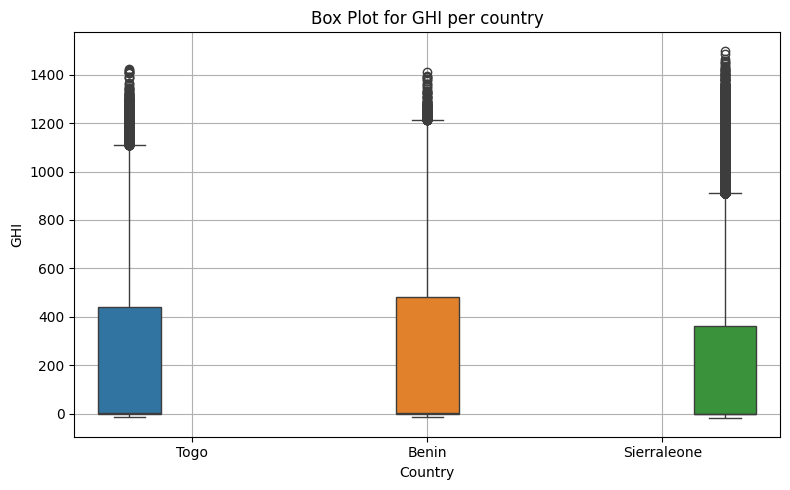

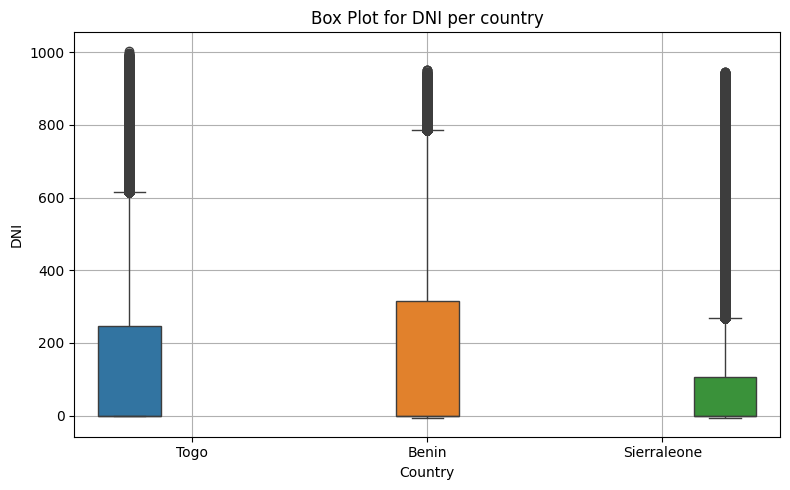

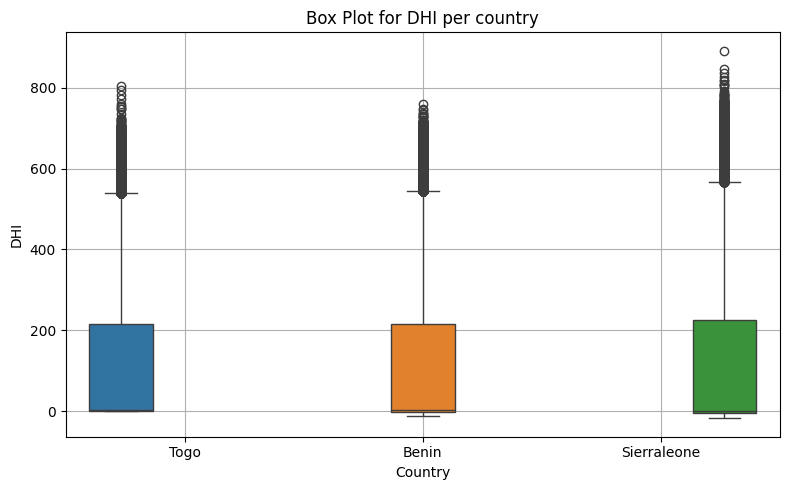

In [ ]:
# Specifying Whihc metics to be plotted
metrics = ['GHI','DNI','DHI']

# Running a for loop to plot each box plot per each metric
for item in metrics:
    plt.figure(figsize=(8,5))
    sns.boxplot(
        data=df,
        x='Country',
        y=item,
        hue='Country',
        dodge=True,
        legend= False
    )

    plt.xlabel('Country')
    plt.ylabel(f'{item}')
    plt.title(f'Box Plot for {item} per country')
    plt.tight_layout()
    plt.grid(True)
    plt.show()

4. Prepare a Summay table Containing Mean, Mode & Median of the Solar Parameters (GHI,DNI & DHI)

In [34]:
#Forming a Summary Panda's DataFrame from the innitial DF grouped by Countires & applying Mean,Mode & STd to Selected Columns

summary_df=df.groupby('Country')[['GHI','DNI','DHI']].agg(['mean','median','std']).reset_index()
summary_df

Country         GHI                            DNI                     \
                      mean median         std        mean median         std   
0        Benin  240.559452    1.8  331.131327  167.187516   -0.1  261.710501   
1  Sierraleone  201.957515    0.3  298.495150  116.376337   -0.1  218.652659   
2         Togo  230.555040    2.1  322.532347  151.258469    0.0  250.956962   

          DHI                     
         mean median         std  
0  115.358961    1.6  158.691074  
1  113.720571   -0.1  158.946032  
2  116.444352    2.5  156.520714

5. Statitstical Testing

In [23]:
# Assigning Groups
groups=[]

for name , group in df.groupby(['Country']):
     groups.append(group['GHI'].dropna().values)

# One Way Annova Test

anova_stat,anova_p =stats.f_oneway(*groups)

# Kruskal_walis test

kruskal_stat,kruskal_p = stats.kruskal(*groups)

# Print the Output of Each Results

print('One way Annova Test')
print(f"F-statistic = {anova_stat:.4f}, p-value = {anova_p:.6f}")

print("\nKruskal–Wallis results:")
print(f"H-statistic = {kruskal_stat:.4f}, p-value = {kruskal_p:.6f}")

One way Annova Test
F-statistic = 2090.0929, p-value = 0.000000

Kruskal–Wallis results:
H-statistic = 4524.8835, p-value = 0.000000


6. Key Observations

1. Mean Irradiance Levels

Benin and Togo show higher mean GHI (≈ 230–240 W/m²) compared to Sierra Leone (≈ 200 W/m²).
➜ Suggests stronger average solar exposure in Benin and Togo.

Similar trends appear for DNI — Benin > Togo > Sierra Leone.
➜ Indicates Benin likely receives the most direct sunlight overall.

2. Variability (Standard Deviation)

All three countries show very high standard deviations relative to their means (std ≈ 300–330 for GHI).
➜ Implies large day-to-day or seasonal variation in solar irradiance.
➜ Possibly due to cloud cover, climate variation, or data aggregation over time.

3. Diffuse Component (DHI)

The DHI means are quite similar across the three countries (≈ 115 W/m²).
➜ Suggests that diffuse solar radiation (from clouds/scattering) is fairly consistent across them.

4. Overall Interpretation

Benin seems to have the most favorable solar potential, with higher average irradiance (GHI/DNI) and similar diffuse levels.

Sierra Leone appears to have lower solar potential and possibly more consistent cloud cover or atmospheric effects.

Togo sits in between but closer to Benin’s profile.

In [28]:
summary_df.head

<bound method NDFrame.head of        Country         GHI                            DNI                     \
                      mean median         std        mean median         std   
0        Benin  240.559452    1.8  331.131327  167.187516   -0.1  261.710501   
1  Sierraleone  201.957515    0.3  298.495150  116.376337   -0.1  218.652659   
2         Togo  230.555040    2.1  322.532347  151.258469    0.0  250.956962   

          DHI                     
         mean median         std  
0  115.358961    1.6  158.691074  
1  113.720571   -0.1  158.946032  
2  116.444352    2.5  156.520714  >

Bonus Plot for Average GHI Values

In [35]:
# Step 1 — Flatten multi-level columns
summary_df.columns = ['Country'] + [f'{col}_{stat}' for col, stat in summary_df.columns[1:]]


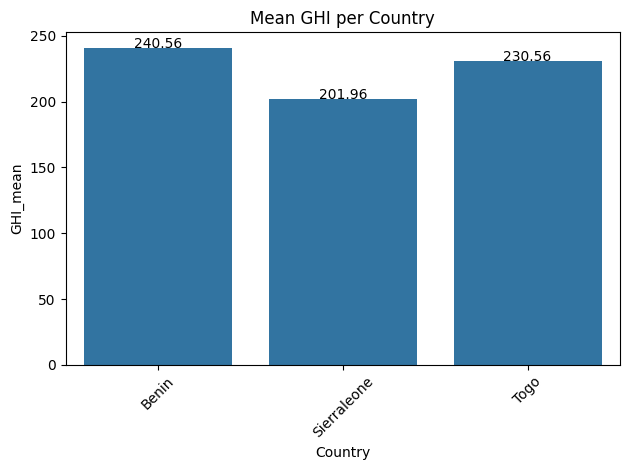

In [37]:
#Step 2 Plot the Bar Chart per Each Country  


# Create the barplot
ax = sns.barplot(data=summary_df, x='Country', y='GHI_mean')
plt.title('Mean GHI per Country')
plt.xticks(rotation=45)

# Add data labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2,  # x-coordinate at the center of the bar
        y=height + 0.05,                  # slightly above the top of the bar
        s=f'{height:.2f}',                # format the label with 2 decimal places
        ha='center'                        # center align horizontally
    )

plt.tight_layout()
plt.show()